### Imports
Import all required libraries used throughout this notebook:
os, numpy: file operations and numerical computing
matplotlib: image visualization
skimage: image loading, grayscale conversion, resizing, and LBP extraction
sklearn: KNN classifier and evaluation metrics

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import local_binary_pattern

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


### Emotion Label Mapping
Mapping between each emotion folder name and the numerical label used by the classifier.
This ensures that the directory structure matches the labels expected by the model.

In [19]:
emotion_map = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "sad": 4,
    "surprise": 5,
    "neutral": 6
}


### Dataset Loading Function
Function that loads the dataset where images are organized into folders by emotion class.

For each image:
- Read the .jpg file
- Convert to grayscale if needed
- Resize to 48×48 pixels (FER-2013 standard)
- Normalize pixel values to uint8
- Store the corresponding numerical label
  
Returns two numpy arrays:
- the processed images
- their associated labels

In [20]:
def load_dataset(root_dir):
    images = []
    labels = []
    
    for emotion_name, label in emotion_map.items():
        folder = os.path.join(root_dir, emotion_name)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            img = imread(img_path)

            if len(img.shape) == 3:  # RGB→Gray
                img = rgb2gray(img)

            img = resize(img, (48,48), anti_aliasing=True)
            img = (img * 255).astype("uint8")

            images.append(img)
            labels.append(label)
            
    return np.array(images), np.array(labels)

### Loading Train and Test Sets
Load the full FER-style dataset by reading all images inside the train and test directories.
- X_train_images: list of 48×48 grayscale images (training)
- y_train: corresponding labels
- Same structure for the test set
  
This step prepares the raw images before feature extraction.

In [21]:
train_dir = "dataset/train"
test_dir = "dataset/test"

X_train_images, y_train = load_dataset(train_dir)
X_test_images, y_test = load_dataset(test_dir)

print("Train:", X_train_images.shape, y_train.shape)
print("Test:", X_test_images.shape, y_test.shape)


Train: (28709, 48, 48) (28709,)
Test: (7178, 48, 48) (7178,)


### LBP Feature Extraction
Extract Local Binary Pattern (LBP) features from a 48×48 grayscale image.

Steps:
- Compute uniform LBP with P = 8 neighbors and radius R = 1
- Divide the image into a 4×4 grid of spatial blocks
- For each block, compute a normalized histogram of LBP codes
- Concatenate all histograms into one feature vector
  
LBP captures local texture patterns (wrinkles, contours, micro-expressions) that are informative for facial expression recognition.

In [22]:
def extract_lbp_features(img, P=8, R=1, blocks=4):
    h, w = img.shape
    lbp = local_binary_pattern(img, P, R, method="uniform")
    block_h, block_w = h // blocks, w // blocks
    features = []
    n_bins = P + 2

    for i in range(blocks):
        for j in range(blocks):
            block = lbp[i*block_h:(i+1)*block_h, j*block_w:(j+1)*block_w]
            hist, _ = np.histogram(block, bins=n_bins, range=(0, n_bins), density=True)
            features.extend(hist)

    return np.array(features)

### Extracting Features for All Images
Apply the LBP feature extraction function to every image in both the training and test sets.

This produces:
- X_train: matrix of LBP feature vectors
- X_test: matrix of LBP feature vectors
  
These features are used as input for the KNN classifier.

In [23]:
X_train = np.array([extract_lbp_features(img) for img in X_train_images])
X_test = np.array([extract_lbp_features(img) for img in X_test_images])

### Training the KNN Classifier
Train a K-Nearest Neighbors classifier on the extracted LBP features.
- k = 5 neighbors
- Euclidean distance metric
  
KNN classifies a new image by comparing it to the closest samples in the feature space.

In [24]:
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


### Evaluation and Performance Metrics
Evaluate the trained model using the test set.

Compute and display:
- Overall accuracy
- Detailed classification report (precision, recall, F1-score per class)
  
This provides a quantitative assessment of how well the LBP + KNN pipeline performs on facial expression recognition.

In [25]:
y_pred = knn.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test accuracy: 0.3166620228475899
              precision    recall  f1-score   support

           0       0.23      0.34      0.27       958
           1       0.34      0.32      0.33       111
           2       0.27      0.28      0.27      1024
           3       0.37      0.47      0.41      1774
           4       0.30      0.19      0.23      1247
           5       0.42      0.37      0.39       831
           6       0.30      0.21      0.25      1233

    accuracy                           0.32      7178
   macro avg       0.32      0.31      0.31      7178
weighted avg       0.32      0.32      0.31      7178



### Single Image Prediction and Visualization
Utility function to display a test image together with the predicted emotion label.

This allows visual inspection of the model’s behavior on individual samples and helps illustrate the results of the classification task.

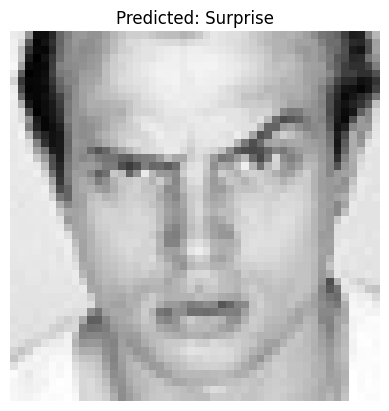

In [26]:
emotion_labels = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]

def show_prediction(i):
    img = X_test_images[i]
    feat = extract_lbp_features(img).reshape(1, -1)
    pred = knn.predict(feat)[0]

    plt.imshow(img, cmap='gray')
    plt.title("Predicted: " + emotion_labels[pred])
    plt.axis("off")
    plt.show()

show_prediction(10)
